Parte 1 – Dados e Análise de Indicadores

In [183]:
#Bibliotecas utilizadas para a analise financeira de ativos
import yfinance as yf
import pandas as pd
import numpy as np
import investpy
import requests
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [184]:
#Download de dados historicos de fechamento de todos os ativos

ibov = yf.download("^BVSP", start="2014-01-01", end="2025-10-05")['Close']

sp500 = yf.download("^GSPC", start="2014-01-01", end="2025-10-05")['Close']

vix = yf.download("^VIX", start="2014-01-01", end="2025-10-05")['Close']

usdb = yf.download("USDBRL=X", start="2014-01-01", end="2025-10-05")['Close']

ouro = yf.download("GC=F", start="2014-01-01", end="2025-10-05")['Close']

url = 'https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json'
res = requests.get(url).json()
ipca = pd.DataFrame(res)
ipca['data'] = pd.to_datetime(ipca['data'], dayfirst=True)
ipca['valor'] = pd.to_numeric(ipca['valor'])
ipca.set_index('data', inplace=True)
ipca = ipca[ipca.index >= '2014-01-01']

C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\8189596.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download("^BVSP", start="2014-01-01", end="2025-10-05")['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\8189596.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2014-01-01", end="2025-10-05")['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\8189596.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", start="2014-01-01", end="2025-10-05")['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\8189596.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True

In [185]:
#Colocar todos em um unico dataframe

ibov = pd.DataFrame(ibov).rename(columns={'Close':'IBOV'})
sp500 = pd.DataFrame(sp500).rename(columns={'Close':'SP500'})
vix = pd.DataFrame(vix).rename(columns={'Close':'VIX'})
usdb = pd.DataFrame(usdb).rename(columns={'Close':'USDBRL'})
ouro = pd.DataFrame(ouro).rename(columns={'Close':'OURO'})
ipca_diario = ipca['valor'].resample('D').ffill()
ipca_diario = pd.DataFrame(ipca_diario).rename(columns={'valor':'IPCA'})

df = pd.concat([ibov, sp500, vix, usdb, ouro, ipca_diario], axis=1)



In [186]:
#Mudar o nome das colunas
df = df.rename(columns={
    '^BVSP': 'ibov',
    '^GSPC': 'sp500',
    '^VIX': 'vix',
    'USDBRL=X': 'usdbrl',
    'GC=F': 'ouro',
    'IPCA': 'ipca'
})
#Remover linhas com valores nulos
df_clean = df.dropna()
df.head(10)
df.index = pd.to_datetime(df.index)




In [187]:
# Garantir que o índice seja do tipo datetime
df.index = pd.to_datetime(df.index)

# Lista de ativos que queremos calcular os retornos
ativos = ['ibov', 'sp500', 'vix', 'usdbrl', 'ouro', 'ipca']

for ativo in ativos:

    df['ret_daily'] = df[ativo].pct_change() * 100

    df['ret_monthly'] = df[ativo].pct_change(21) * 100 

    df['ret_year'] = df[ativo].pct_change(252) * 100 

#Calculo da voltalidade diaria, mensal e anual

ativos = ['ibov', 'sp500', 'vix', 'usdbrl', 'ouro', 'ipca']

# Calcular volatilidade para cada ativo
for ativo in ativos:
    # Retorno diário
    df[f'ret_daily_{ativo}'] = df[ativo].pct_change() * 100

    df[f'vol_daily_{ativo}'] = df[f'ret_daily_{ativo}'].rolling(window=1).std()

    df[f'vol_21dias_{ativo}'] = df[f'ret_daily_{ativo}'].rolling(window=21).std()

    df[f'vol_252dias_{ativo}'] = df[f'ret_daily_{ativo}'].rolling(window=252).std()




C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\713825985.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['ret_daily'] = df[ativo].pct_change() * 100
C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\713825985.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['ret_monthly'] = df[ativo].pct_change(21) * 100
C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\713825985.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=N

C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\1643562401.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos_diarios = df[ativos].pct_change()


                  ret_daily_ibov  ret_daily_sp500  ret_daily_vix  \
ret_daily_ibov          1.000000         0.504052      -0.371333   
ret_daily_sp500         0.504052         1.000000      -0.726215   
ret_daily_vix          -0.371333        -0.726215       1.000000   
ret_daily_usdbrl        0.010056         0.000391      -0.018257   
ret_daily_ouro          0.043782         0.014172       0.046197   
ret_daily_ipca          0.007899         0.016228      -0.015449   

                  ret_daily_usdbrl  ret_daily_ouro  ret_daily_ipca  
ret_daily_ibov            0.010056        0.043782        0.007899  
ret_daily_sp500           0.000391        0.014172        0.016228  
ret_daily_vix            -0.018257        0.046197       -0.015449  
ret_daily_usdbrl          1.000000       -0.027689        0.015914  
ret_daily_ouro           -0.027689        1.000000       -0.004531  
ret_daily_ipca            0.015914       -0.004531        1.000000  


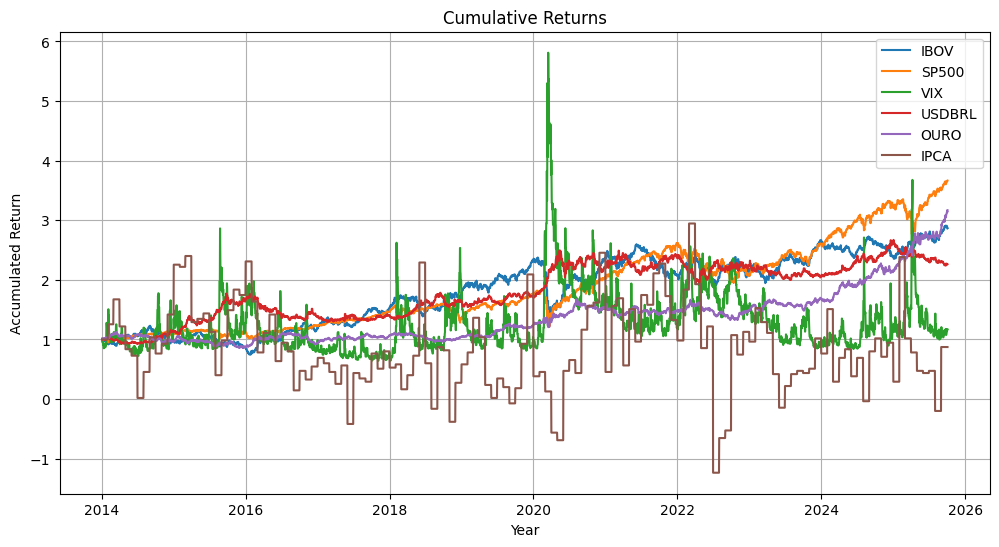

In [188]:
# Selecionar apenas as colunas de retorno diário
retornos_diarios = df[[f'ret_daily_{ativo}' for ativo in ativos]]

# Calcular a matriz de correlação
correlacao = retornos_diarios.corr()

print(correlacao)


# Lista de ativos
ativos = ['ibov', 'sp500', 'vix', 'usdbrl', 'ouro', 'ipca']

# Calcular retorno diário
retornos_diarios = df[ativos].pct_change()

# Calcular retorno acumulado
retornos_acumulados = (1 + retornos_diarios).cumprod()

# Plotar gráfico
plt.figure(figsize=(12,6))
for ativo in ativos:
    plt.plot(retornos_acumulados.index, retornos_acumulados[ativo], label=ativo.upper())

plt.title('Cumulative Returns')
plt.xlabel('Year')
plt.ylabel('Accumulated Return')
plt.legend()
plt.grid(True)
plt.show()

In [189]:
#Rank de Risco com Metodo VaR

conf_level = 0.95

# Lista de ativos
ativos = ['ibov', 'sp500', 'vix', 'usdbrl', 'ouro', 'ipca']

# Criar um dicionário para armazenar VaR
var_dict = {}

for ativo in ativos:
    # Retorno diário em %
    df[f'ret_diario_{ativo}'] = df[ativo].pct_change() * 100
    
    # Calcular VaR 95%
    var_95 = np.percentile(df[f'ret_diario_{ativo}'].dropna(), 100*(1-conf_level))
    var_dict[ativo] = var_95

# Transformar em DataFrame e ordenar
var_df = pd.DataFrame(list(var_dict.items()), columns=['Ativo', 'VaR_95'])
var_df = var_df.sort_values(by='VaR_95')

print(var_df)


    Ativo    VaR_95
2     vix -9.201947
0    ibov -1.831461
3  usdbrl -1.357309
1   sp500 -1.351804
4    ouro -1.271141
5    ipca  0.000000


C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\2364451209.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'ret_diario_{ativo}'] = df[ativo].pct_change() * 100
C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\2364451209.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'ret_diario_{ativo}'] = df[ativo].pct_change() * 100
C:\Users\joaop\AppData\Local\Temp\ipykernel_3576\2364451209.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or sp